In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import os
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

df=pd.DataFrame(cancer.data,columns=cancer.feature_names)
df['target']=cancer.target
print(df.shape)
print(df.head())
print(df.columns.to_list())


(569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0   

In [26]:
print(cancer.target_names)  # what do 0 and 1 mean?
print(pd.Series(cancer.target).value_counts())

['malignant' 'benign']
1    357
0    212
Name: count, dtype: int64


In [27]:
correlation=df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlation)

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

<Axes: xlabel='target', ylabel='worst concave points'>

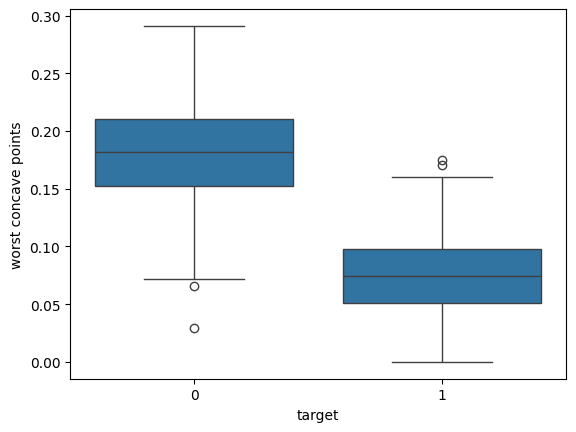

In [28]:
sns.boxplot(x='target', y='worst concave points', data=df)

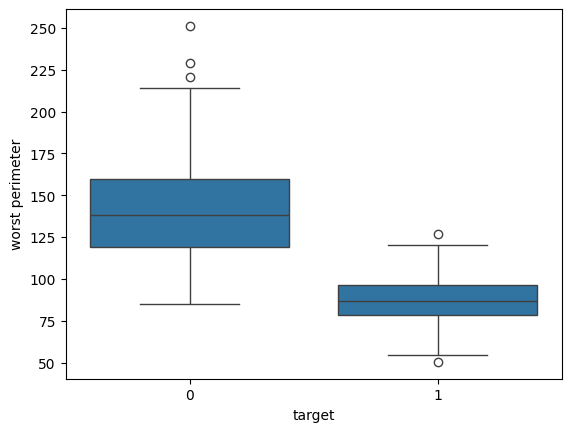

In [29]:
sns.boxplot(x='target', y='worst perimeter', data=df)

plt.show()

<Axes: xlabel='target', ylabel='worst radius'>

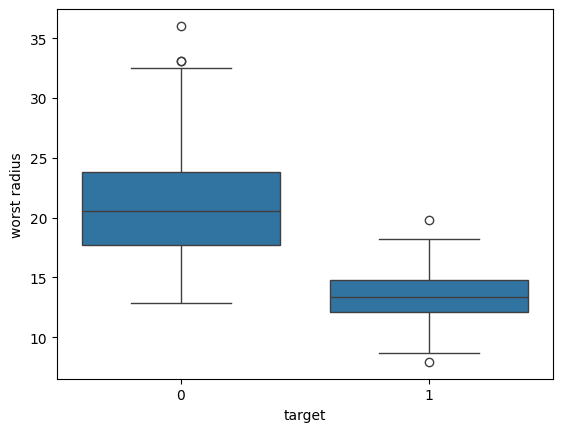

In [30]:
sns.boxplot(x='target',y='worst radius',data=df)

In [31]:
X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [35]:
#Logistic Regression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test,y_pred): .4f}")
print(confusion_matrix (y_test,y_pred))
print(classification_report(y_test,y_pred))

coefficients = pd.Series(model.coef_[0],index=X.columns)
print(coefficients.sort_values(ascending=False))

Accuracy :  0.9737
[[41  2]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

compactness error          0.669066
fractal dimension error    0.611761
mean compactness           0.526717
symmetry error             0.504999
mean symmetry              0.241538
texture error              0.188993
concavity error            0.171077
mean fractal dimension     0.078447
worst compactness          0.005897
mean smoothness           -0.067394
worst fractal dimension   -0.162932
concave points error      -0.314317
smoothness error          -0.316570
mean perimeter            -0.396070
mean texture              -0.397194
mean radius               -0.434647
mean area                 -0.469990
worst smoothness       

In [39]:
param_grid= {
    'n_estimators' : [50,100,200],
    'max_depth' : [3,5,7,None],
    'min_samples_split' : [2,5,10]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid_search.fit(X_train,y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred=best_model.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test,y_pred): .4f}")
print(confusion_matrix (y_test,y_pred))
print(classification_report(y_test,y_pred))


{'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
0.9626373626373625
Accuracy :  0.9649
[[40  3]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [40]:
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

grid_search_xgb.fit(X_train, y_train)

print(f"Best params: {grid_search_xgb.best_params_}")
best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Best params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.9561
[[40  3]
 [ 2 69]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

